# Case study: Qualitative analysis and quantitative analysis on the polarization test

This manuscript aims to investigate the phenomenon of the observed higher concentration loss at high temperature.

Recall the last discussion, we draw the following argument:

1. At high temperature, the temperature of the humidifier supply didn't match the stack temperature which was well controller by the cooling circuit.

2. The vapor condense immediately at the interface, and thus we can observe a higher concentration loss at high temperature

Another possibility may be also exist: 

3. According to some existing literature, oxygen resistance was found became higher when the RH was low. Thus, at the 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import re
from scipy.integrate import solve_ivp
from pathlib import Path
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from config.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from data.export import export_experiment_data

ModuleNotFoundError: No module named 'configuration'

In [ ]:
# Load all polarization curves
all_pola = export_experiment_data("pola")
# Returns: {"T50_P300_HRC50": DataFrame, "T50_P300_HRC0": DataFrame, ...}
# Load all HFR measurements
all_hfr = export_experiment_data("hfr")
# Load all auxiliary data
all_aux = export_experiment_data("auxiliary")
# Returns: {"RHA0/RHC0.5_P1.3_T50": DataFrame, ...}
# Load all EIS spectra
all_eis = export_experiment_data("eis")
# Returns: {"RHC0.5_P1.3_T50": [DataFrame, DataFrame, ...], ...}

## Humidity actuator and thermal controller performance

Firstly, the humidity sensor data was presented:

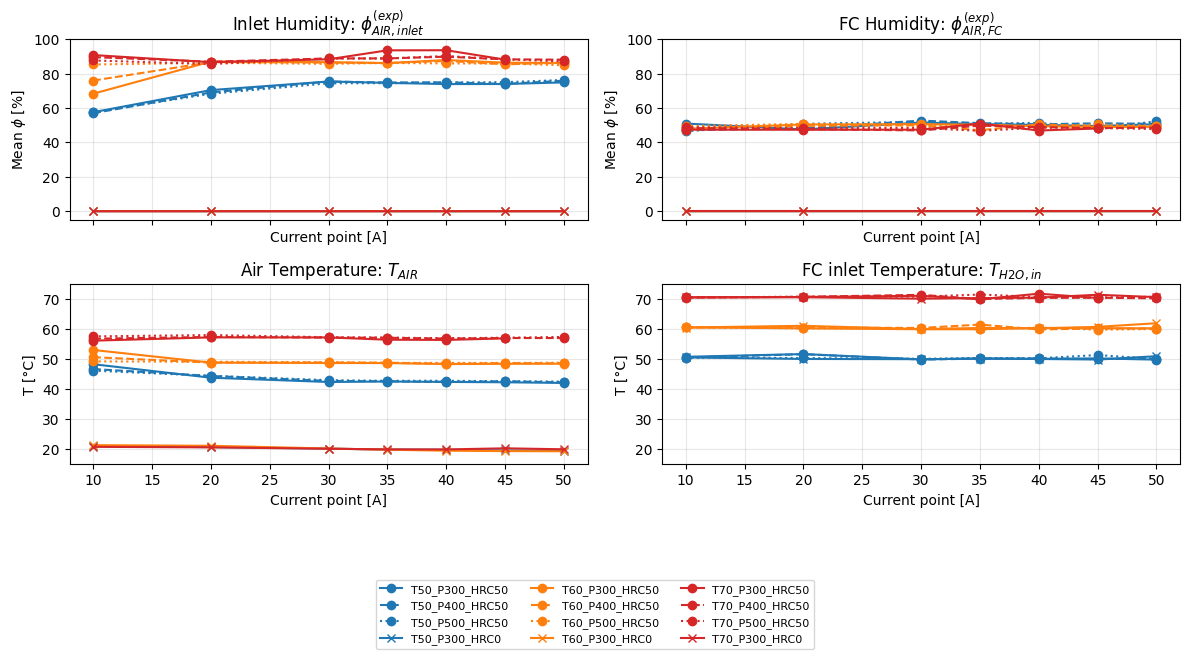

In [ ]:
mean_by_condition = {}
for condition, df in all_aux.items():
    summary = df.assign(I_POINT=df["I_LOAD"].round()).groupby("I_POINT", as_index=False)[["HR_AIR_Gaz", "HR_AIR_FC", "T_AIR", "T_H2O_IN"]].mean().sort_values("I_POINT")
    mean_by_condition[condition] = summary

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharex=True)
for condition, summary in mean_by_condition.items():
    t = int(re.search(r"T(\d+)", condition).group(1))
    p_bar = {300: 1.3, 400: 1.4, 500: 1.5}[int(re.search(r"P(\d+)", condition).group(1))]
    rh_frac = int(re.search(r"HRC(\d+)", condition).group(1)) / 100
    init_cond_key = f"RHA0/RHC{rh_frac:g}_P{p_bar:.1f}_T{t}"
    props = get_plot_properties(init_cond_key)
    axes[0, 0].plot(summary["I_POINT"], summary["HR_AIR_Gaz"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)
    axes[0, 1].plot(summary["I_POINT"], summary["HR_AIR_FC"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)
    axes[1, 0].plot(summary["I_POINT"], summary["T_AIR"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)
    axes[1, 1].plot(summary["I_POINT"], summary["T_H2O_IN"], color=props["color"], linestyle=props["linestyle"], marker=props["marker"], linewidth=1.5, label=condition)

for ax in axes.flatten():
    ax.set_xlabel("Current point [A]"); ax.grid(True, alpha=0.3)

axes[0, 0].set_title(r"Inlet Humidity: $\phi_{AIR,inlet}^{(exp)}$")
axes[0, 0].set_xlabel("Current point [A]")
axes[0, 0].set_ylabel(r"Mean $\phi$ [%]")
axes[0, 1].set_title(r"FC Humidity: $\phi_{AIR,FC}^{(exp)}$")
axes[0, 1].set_ylabel(r"Mean $\phi$ [%]")
axes[0, 0].set_ylim(-5, 100)
axes[0, 1].set_ylim(-5, 100)
axes[1, 0].set_ylim(15, 75)
axes[1, 1].set_ylim(15, 75)
axes[1, 0].set_title(r"Air Temperature: $T_{AIR}$")
axes[1, 0].set_ylabel("T [°C]")
axes[1, 1].set_title(r"FC inlet Temperature: $T_{H2O,in}$")
axes[1, 1].set_ylabel("T [°C]")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=8, frameon=True)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

In order to investigate the impact of the vapor flow to the tranportation, we need to refer to the EIS spectrums under all operation condition/ 

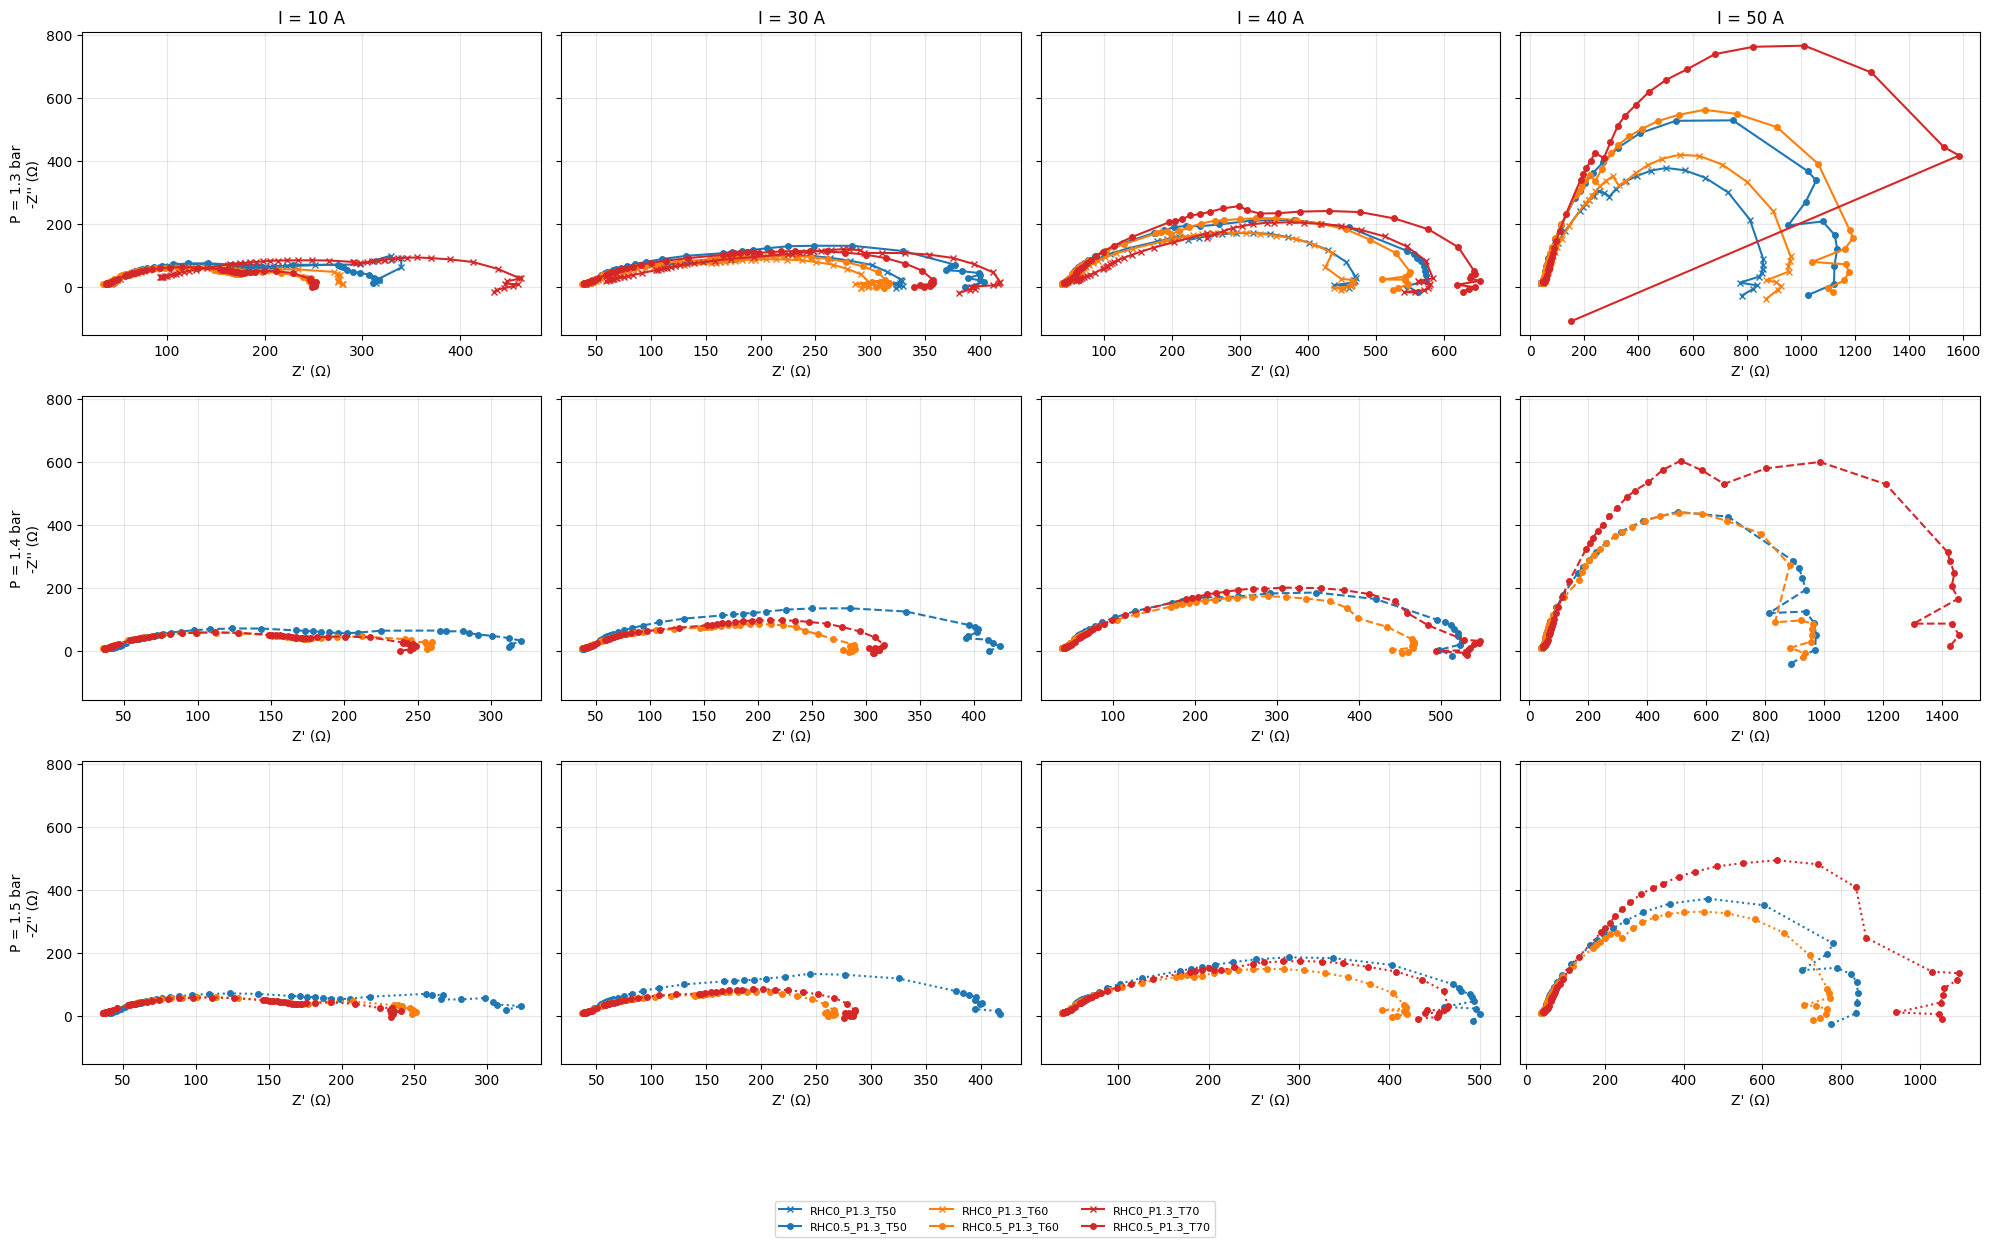

In [ ]:
I_POINTS  = [10, 30, 40, 50]
P_BARS    = [1.3, 1.4, 1.5]
p_tag_to_bar = {3.0: 1.3, 4.0: 1.4, 5.0: 1.5}

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)

for row, p_bar in enumerate(P_BARS):
    for col, I in enumerate(I_POINTS):
        ax = axes[row, col]

        for key, df in all_eis.items():
            if not key.startswith(f"I{I}_"):
                continue

            rhc   = float(re.search(r"RHC([\d.]+)", key).group(1))
            p_tag = float(re.search(r"_P([\d.]+)", key).group(1))
            t     = int(re.search(r"T(\d+)", key).group(1))

            if p_tag_to_bar[p_tag] != p_bar:
                continue

            cond_key = f"RHA0/RHC{rhc:g}_P{p_bar:.1f}_T{t}"
            props = get_plot_properties(cond_key)

            ax.plot(df.iloc[:, 4], -df.iloc[:, 5],
                    color=props["color"], linestyle=props["linestyle"],
                    marker=props["marker"],
                    linewidth=1.5, markersize=4, label=cond_key[5:])

        ax.set_xlabel("Z' (Ω)")
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel(f"P = {p_bar} bar\n-Z'' (Ω)")
        if row == 0:
            ax.set_title(f"I = {I} A")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=3, fontsize=8, frameon=True)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


From the spectrum, we can observe the following phenomenon that related to the water:

1. The low frequency arc of the 0 RH spectrum was larger before 30A current region even account for the offset that yield by the higher HFR.